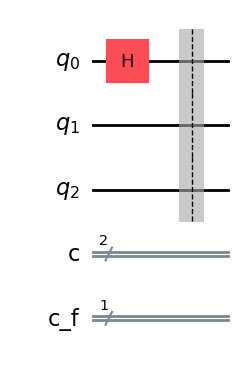

In [ ]:
# Importing required modules
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import depolarizing_error

# Step 1: Initialize Quantum and Classical Registers
q = QuantumRegister(3, 'q')  # 3 qubits: q0 (state to teleport), q1 (Alice's entangled qubit), q2 (Bob's entangled qubit)
c = ClassicalRegister(2, 'c')  # 2 classical bits to store Alice's measurement results
c_final = ClassicalRegister(1, 'c_f') #  1 classical bit to store a final measurement on the data qubit
teleportation_circuit = QuantumCircuit(q, c, c_final)

# Step 2: Prepare the state to be teleported
teleportation_circuit.h(q[0])  # Let's create a superposition state as an example |ψ⟩ = (|0⟩ + |1⟩)/√2
teleportation_circuit.barrier() # we are sure that the gates put on the left of the barrier are executed before the ones on the right

# Visualization
teleportation_circuit.draw('mpl')

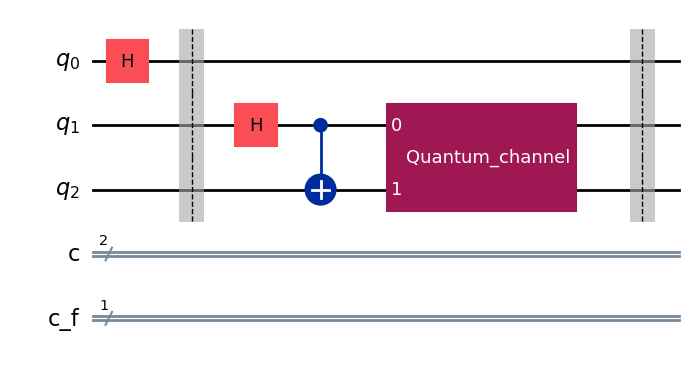

In [ ]:
# Step 3: Create entanglement between Alice's and Bob's qubits
teleportation_circuit.h(q[1])
teleportation_circuit.cx(q[1], q[2])

# apply a depolarizing channel to the Bell pair with probability pw
pw = 0.1
error_bell = depolarizing_error(pw, 2)

# append the error to the Bell pair (qubits 1 and 2)
teleportation_circuit.append(error_bell, [1, 2])

teleportation_circuit.barrier()

# Visualization
teleportation_circuit.draw('mpl')

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


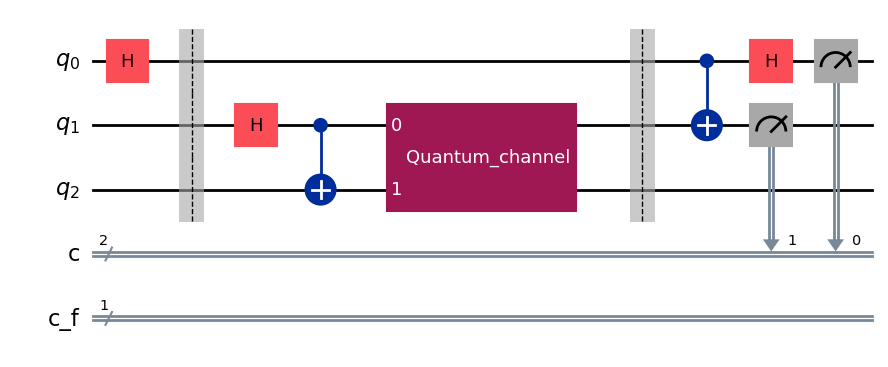

In [21]:
# Alice applies a quantum measurement in the Bell basis
teleportation_circuit.cx(q[0], q[1])
teleportation_circuit.h(q[0])

teleportation_circuit.measure(q[0:2], c[0:2])

# Visualization
teleportation_circuit.draw('mpl')

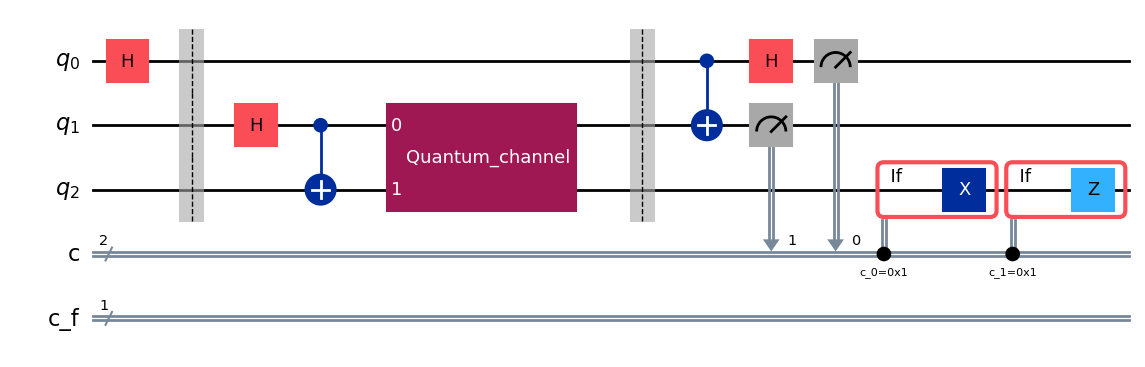

In [22]:
# Step 6: Bob applies correction gates based on Alice's classical results
with teleportation_circuit.if_test((c[0], 1)):
    teleportation_circuit.x(q[2])
with teleportation_circuit.if_test((c[1], 1)):
    teleportation_circuit.z(q[2])

# Visualization
teleportation_circuit.draw('mpl')